# Ex 05 - DEVELOPING A RECURRENT NEURAL NETWORK MODEL FOR STOCK PREDICTION

**NAME:** Ramya P        **REG NO:** 212223230168           **SLOT:** 26OD1143



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
## Step 1: Load and Preprocess Data

df_train = pd.read_csv('trainset.csv')
df_test = pd.read_csv('testset.csv')

print("Training data shape:", df_train.shape)
print("Test data shape:", df_test.shape)
print("Columns:", df_train.columns.tolist())

Training data shape: (1259, 7)
Test data shape: (125, 7)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [3]:
# Use closing prices

train_prices = df_train['Close'].values.reshape(-1, 1)
test_prices = df_test['Close'].values.reshape(-1, 1)

print("Training prices:", train_prices.shape)
print("Test prices:", test_prices.shape)

Training prices: (1259, 1)
Test prices: (125, 1)


In [4]:
# Normalize the data based on training set only

scaler = MinMaxScaler()

scaled_train = scaler.fit_transform(train_prices)
scaled_test = scaler.transform(test_prices)

In [5]:
# Create sequences

def create_sequences(data, seq_length):
    x = []
    y = []

    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(x), np.array(y)


seq_length = 60

x_train, y_train = create_sequences(scaled_train, seq_length)
x_test, y_test = create_sequences(scaled_test, seq_length)

In [6]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((1199, 60, 1), (1199, 1), (65, 60, 1), (65, 1))

In [7]:
# Convert to PyTorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


In [8]:
# Create dataset and dataloader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [9]:
## Step 2: Define RNN Model

class RNNModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2,
        output_size=1
    ):
        super(RNNModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self, x):

        h0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size,
            device=x.device
        )

        out, _ = self.rnn(x, h0)

        # Take the output from the last time step
        out = out[:, -1, :]

        # Fully connected layer
        out = self.fc(out)

        return out

In [10]:
model = RNNModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [11]:
!pip install torchinfo

In [12]:
from torchinfo import summary

# input_size = (batch_size, seq_len, input_size)
summary(model, input_size=(64, 60, 1))

Layer (type:depth-idx)                   Output Shape              Param #
RNNModel                                 [64, 1]                   --
├─RNN: 1-1                               [64, 60, 64]              12,608
├─Linear: 1-2                            [64, 1]                   65
Total params: 12,673
Trainable params: 12,673
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 48.42
Input size (MB): 0.02
Forward/backward pass size (MB): 1.97
Params size (MB): 0.05
Estimated Total Size (MB): 2.03

In [13]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [14]:
## Step 3: Train the Model

epochs = 50

train_losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for inputs, targets in train_loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Calculate loss
        loss = criterion(outputs, targets)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    train_losses.append(epoch_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {epoch_loss:.6f}"
        )

Epoch [1/50], Loss: 0.102087
Epoch [5/50], Loss: 0.000522
Epoch [10/50], Loss: 0.000398
Epoch [15/50], Loss: 0.000348
Epoch [20/50], Loss: 0.000345
Epoch [25/50], Loss: 0.000315
Epoch [30/50], Loss: 0.000296
Epoch [35/50], Loss: 0.000284
Epoch [40/50], Loss: 0.000281
Epoch [45/50], Loss: 0.000323
Epoch [50/50], Loss: 0.000272


Name: Your Name
Register Number: Your Register Number


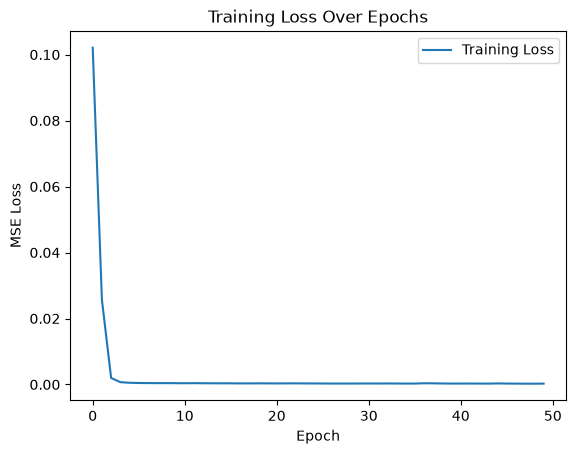

In [15]:
# Plot training loss

print("Name: Your Name")
print("Register Number: Your Register Number")

plt.plot(train_losses,label='Training Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Over Epochs')

plt.legend()
plt.show()

Name: Your Name
Register Number: Your Register Number


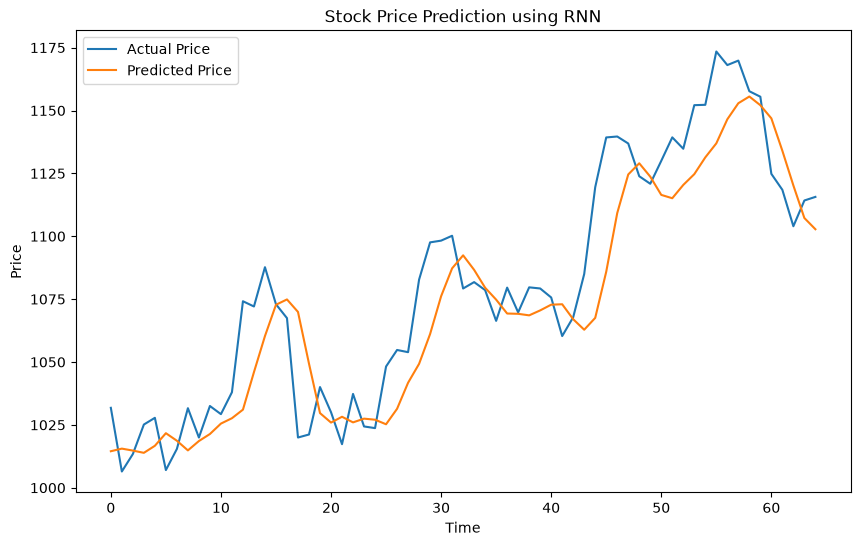

Predicted Price: [1102.7932]
Actual Price: [1115.65]


In [16]:
## Step 4: Make Predictions on Test Set

model.eval()

with torch.no_grad():

    predicted = model(
        x_test_tensor.to(device)
    ).cpu().numpy()

    actual = y_test_tensor.cpu().numpy()


# Inverse transform the predictions and actual values

predicted_prices = scaler.inverse_transform(predicted)

actual_prices = scaler.inverse_transform(actual)


# Plot predictions vs actual prices

print("Name: Your Name")
print("Register Number: Your Register Number")

plt.figure(figsize=(10, 6))

plt.plot(actual_prices,label='Actual Price')

plt.plot(predicted_prices,label='Predicted Price')

plt.xlabel('Time')
plt.ylabel('Price')

plt.title('Stock Price Prediction using RNN')

plt.legend()
plt.show()


print(f"Predicted Price: {predicted_prices[-1]}")

print(f"Actual Price: {actual_prices[-1]}")